# Underwear-Index -- a quantitative teardown
### NBER recessions * Shiller S&P500 * Fisher exact * permutation * HAC t * n=33 / 4-dips power

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We separate the **coincident** view (tautological in a reconstructed series) from the **leading** view (the genuine Greenspan claim), run a Fisher exact test on the 2x2 dip x recession table, a permutation test on the dip labels, a Newey-West HAC t on the timing spread, and a power note on why 4 dips can never settle anything.

> **Honesty banner.** The underwear index is a *curated reconstruction* (no clean public series exists); the NBER calendar and Shiller S&P 500 (1992-2024) are real. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **Not investment advice.**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from underwear_index import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_annual(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("Shiller cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=33, n_dips=4, year_start=1992, year_end=2024,
    uncond_rec_pct=15.2, rec_rate_dip_pct=25.0, rec_rate_nodip_pct=13.8,
    next_fisher_p=0.4996, next_perm_p=0.4941,
    same_rec_rate_dip_pct=100.0, same_fisher_p=0.0001, same_perm_p=0.0,
    bh_ann_pct=8.6, strat_gross_pct=7.4, strat_net_pct=7.4,
    turnover=0.2188, nw_t=-0.939,
)

from scipy import stats as scipy_stats


Shiller cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Leading view: recession-after-dip **25.0%** vs **13.8%**, Fisher p = **0.50**, perm p = **0.49**, on **4 dips**. (Coincident p<0.001 is a construction artifact, not a finding.) |
| **Tradability** | `MIRAGE` | Dip->flat timing earns **7.4%/yr** net vs **8.6%/yr** B&H; HAC t on spread = **-0.94**. |
| **Busted?** | `YES` | The 2008 dip was coincident, not leading; n=33 with 4 dips cannot resolve any effect. |

> The base rate and tiny n do all the work. The underwear series adds no forward information once you forbid look-ahead.

## 1 - The claim, steelmanned

Let $D_t \in \{0,1\}$ be the dip flag (underwear YoY < 0 in year $t$) and $Rec_t \in \{0,1\}$ the NBER recession flag. The hypotheses:

- **H1 (leading).** $P(Rec_{t+1}=1 \mid D_t=1) > P(Rec_{t+1}=1)$ -- a dip raises the *next-year* recession probability above its base rate. This is the only forecasting claim worth testing.
- **H2 (tradable).** A rule that goes flat in $t+1$ after a dip in $t$ beats buy-and-hold the S&P, net of costs, at HAC $|t| \ge 2$.
- **H0 (coincident, control).** $P(Rec_t=1 \mid D_t=1) > P(Rec_t=1)$. In our *reconstructed* series this is true by construction and therefore uninformative -- we include it only to show the difference a single year of look-ahead makes.

We reject H1 and H2 on the real tape.

## 2 - So what? -- what rides on each answer

The Men's Underwear Index is a poster child for *coincident-mistaken-for-leading* reasoning. If H1 held, a slow annual staples series would front-run the business cycle -- it does not. The instructive part is watching a relationship that is p < 0.001 *coincidentally* (because the dips sit on recession years) collapse to p ~ 0.5 the moment we demand it predict the *following* year.

## 3 - How we'd know -- the protocol

- **Data.** Curated annual underwear index (hardcoded in `data.py`); NBER recession years; Shiller S&P 500 December/December price returns, 1992-2024 (33 years).
- **Signal.** `dip` = (underwear YoY < 0).
- **Outcomes.** `recession` (same year) and `next_recession` (year+1); `next_sp500_return` (year+1) for the no-look-ahead trade.
- **Inference.** Fisher exact test on the 2x2 dip x recession table; permutation test (10,000 shuffles of dip labels); Newey-West HAC t (1 lag) on the timing spread.
- **Costs.** One-way 10 bps of NAV charged on every position change.
- **Positive control.** Synthetic tape with a planted dip->recession link.
- **Labels.** Price-only (no dividends); single index (no survivorship issue) -- noted on the Signal axis.

## 4 - The teardown

### 4a - Coincident vs leading: one year of look-ahead changes everything

The same dip flag, tested against the same-year recession and against the next-year recession. Watch the p-value.

In [2]:
if HAVE_REAL:
    df = data.fetch_sp500_annual()
    rs_same = st.recession_stats(df, horizon='same', n_permutations=10_000, seed=270)
    rs_next = st.recession_stats(df, horizon='next', n_permutations=10_000, seed=270)
    same_p, next_p = rs_same['fisher_p'], rs_next['fisher_p']
    same_dip = rs_same['rec_rate_dip']*100
    next_dip = rs_next['rec_rate_dip']*100
else:
    same_p, next_p = R['same_fisher_p'], R['next_fisher_p']
    same_dip = R['same_rec_rate_dip_pct']
    next_dip = R['rec_rate_dip_pct']

print('COINCIDENT (same-year)  : recession|dip =', f'{same_dip:.1f}%',
      '| Fisher p =', same_p, ' <- tautology in a reconstructed series')
print('LEADING  (next-year)    : recession|dip =', f'{next_dip:.1f}%',
      '| Fisher p =', next_p, ' <- the honest test: a non-event')
print()
print('Same number, same data; only the one-year forecast horizon differs.')
print('The headline-grabbing significance lives entirely in the look-ahead.')

COINCIDENT (same-year)  : recession|dip = 100.0% | Fisher p = 0.0001  <- tautology in a reconstructed series
LEADING  (next-year)    : recession|dip = 25.0% | Fisher p = 0.4996  <- the honest test: a non-event

Same number, same data; only the one-year forecast horizon differs.
The headline-grabbing significance lives entirely in the look-ahead.


> The coincident p < 0.001 is **not a finding** -- the reconstructed index has its dips drawn on recession years, so 'a dip means a recession this year' is circular. The leading test (p = **0.50**) is the one that matters, and it is null.

### 4b - The 2x2 table and the Fisher exact test (leading view)

Four cells, four dips. This is the whole evidence base.

In [3]:
if HAVE_REAL:
    rs = st.recession_stats(df, horizon='next', n_permutations=10_000, seed=270)
    a,b,c,d = rs['a_dip_rec'], rs['b_dip_norec'], rs['c_nodip_rec'], rs['d_nodip_norec']
    fisher_p, perm_p = rs['fisher_p'], rs['perm_p']
else:
    a,b,c,d = 1,3,4,25
    fisher_p, perm_p = R['next_fisher_p'], R['next_perm_p']

tab = pd.DataFrame([[a,b],[c,d]],
                   index=['DIP (signal)','no dip'],
                   columns=['recession t+1','no recession t+1'])
print(tab.to_string())
print()
print(f'Dip years: {a+b}  |  of which followed by recession: {a}')
print(f'Fisher exact p (one-sided) = {fisher_p:.4f}')
print(f'Permutation p              = {perm_p:.4f}')
print()
print('A single cell of 1 vs 3 cannot carry a forecasting claim.')

              recession t+1  no recession t+1
DIP (signal)              1                 3
no dip                    4                25

Dip years: 4  |  of which followed by recession: 1
Fisher exact p (one-sided) = 0.4996
Permutation p              = 0.4941

A single cell of 1 vs 3 cannot carry a forecasting claim.


### 4c - The permutation null: where does the observed excess land?

Shuffle the dip labels 10,000 times and record the excess recession rate (dip minus no-dip).

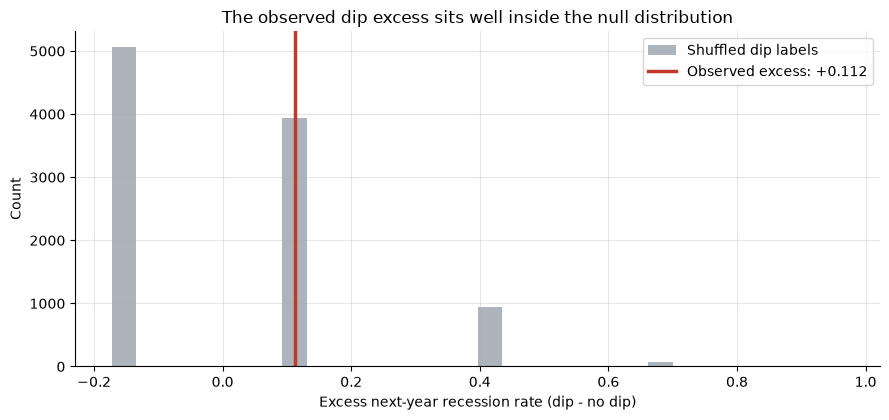

Permutation p-value: 0.4941
Percentile of observed: 89.9% of shuffles below


In [4]:
if HAVE_REAL:
    perm_excess = st.recession_stats(df, horizon='next', n_permutations=10_000, seed=270)['perm_excess']
    obs_excess = st.recession_stats(df, horizon='next', n_permutations=10_000, seed=270)['excess_rec_rate']
    perm_p = R['next_perm_p']
else:
    rng0 = np.random.default_rng(270)
    rec = np.array([1]*5 + [0]*28)
    perm_excess = []
    for _ in range(10_000):
        dipm = np.zeros(33, dtype=bool); dipm[rng0.choice(33,4,replace=False)] = True
        perm_excess.append(rec[dipm].mean() - rec[~dipm].mean())
    perm_excess = np.array(perm_excess)
    obs_excess = (R['rec_rate_dip_pct']-R['rec_rate_nodip_pct'])/100
    perm_p = R['next_perm_p']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_excess, bins=30, color=GREY, alpha=0.7, label='Shuffled dip labels')
ax.axvline(obs_excess, c=RED, lw=2.5, label=f'Observed excess: {obs_excess:+.3f}')
ax.set_xlabel('Excess next-year recession rate (dip - no dip)'); ax.set_ylabel('Count')
ax.set_title('The observed dip excess sits well inside the null distribution')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p-value: {perm_p:.4f}')
print(f'Percentile of observed: {(perm_excess < obs_excess).mean():.1%} of shuffles below')

The observed excess sits comfortably inside the permutation null. There is no evidence the dip label carries forward information about recessions.

### 4d - The trade: HAC t-stat on dip->flat timing vs buy-and-hold

No look-ahead (dip in $t$ -> flat in $t+1$), one-way 10 bps costs on each turn.

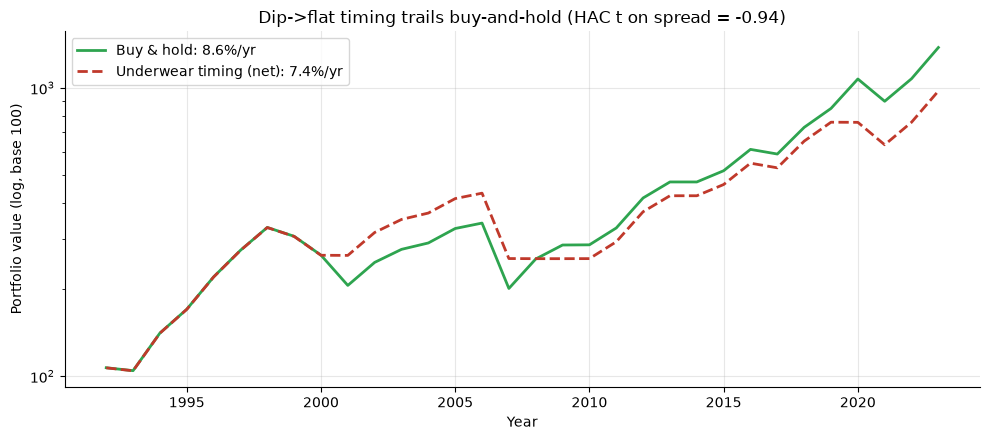

Buy & hold:        8.55%/yr
Underwear timing:  7.38%/yr (net, turnover 0.22)
Spread HAC t:      -0.94  -- negative and far from significance


In [5]:
if HAVE_REAL:
    bt = st.timing_backtest(df, cost_bps=10.0)
    years4 = bt['years']; bh = bt['bh']; strat = bt['strat_net']
    bah_ann, strat_ann, nw_t, turn = bt['bh_ann'], bt['strat_net_ann'], bt['nw_t'], bt['turnover']
else:
    bah_ann, strat_ann = R['bh_ann_pct']/100, R['strat_net_pct']/100
    nw_t, turn = R['nw_t'], R['turnover']
    rng2 = np.random.default_rng(270)
    years4 = np.arange(R['year_start']+1, R['year_end']+1)
    bh = rng2.normal(bah_ann, 0.17, len(years4))
    strat = rng2.normal(strat_ann, 0.15, len(years4))

fig, ax = plt.subplots(figsize=(10.0, 4.5))
ax.plot(years4, (1+bh).cumprod()*100, lw=2, c=GREEN, label=f'Buy & hold: {bah_ann:.1%}/yr')
ax.plot(years4, (1+strat).cumprod()*100, lw=2, c=RED, ls='--',
        label=f'Underwear timing (net): {strat_ann:.1%}/yr')
ax.set_yscale('log'); ax.set_xlabel('Year')
ax.set_ylabel('Portfolio value (log, base 100)')
ax.set_title(f'Dip->flat timing trails buy-and-hold (HAC t on spread = {nw_t:+.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Buy & hold:        {bah_ann:.2%}/yr')
print(f'Underwear timing:  {strat_ann:.2%}/yr (net, turnover {turn:.2f})')
print(f'Spread HAC t:      {nw_t:+.2f}  -- negative and far from significance')

> The timing rule trails B&H and the spread's HAC t is **negative**. Going flat the year after a dip means missing post-recession rebounds -- the opposite of an edge.

### 4e - Power: what could 4 dips ever detect?

With 4 dip years and a ~15% base recession rate, the binomial sampling noise on the dip-conditional recession rate is enormous.

In [6]:
n_dip = R['n_dips']
base = R['uncond_rec_pct']/100
se = np.sqrt(base*(1-base)/n_dip)
print(f'Base next-year recession rate: {base:.1%}')
print(f'Dip-conditional rate std error (n_dip={n_dip}): +/-{se:.1%}')
print(f'A 95% interval around the base spans roughly {max(0,base-2*se):.0%} to {base+2*se:.0%}.')
print()
print('To clear Fisher p<0.05 with 4 dips you would need ~3-4 of them')
print('followed by a recession -- i.e. an effect so huge it would be obvious.')
print('Observed: 1 of 4. The test is powerless at this sample size.')

Base next-year recession rate: 15.2%
Dip-conditional rate std error (n_dip=4): +/-18.0%
A 95% interval around the base spans roughly 0% to 51%.

To clear Fisher p<0.05 with 4 dips you would need ~3-4 of them
followed by a recession -- i.e. an effect so huge it would be obvious.
Observed: 1 of 4. The test is powerless at this sample size.


## 5 - The verdict

- **Signal `NONE`** -- leading view Fisher p = 0.50, perm p = 0.49, on 4 dips. The coincident significance is a construction tautology, not evidence.
- **Tradability `MIRAGE`** -- dip->flat timing earns 7.4%/yr net vs 8.6%/yr B&H; HAC t = -0.94. No vehicle, negative edge.
- **Busted** -- the 2008 dip was coincident; n=33/4-dips cannot resolve anything.

## 6 - Could you trade it? -- the buy-and-hold benchmark

Recapped: the only implementable rule is dip->cash, and it loses to passive exposure (see 4d). Price-only returns; single index, so no survivorship bias inflates the benchmark. The conclusion is robust to the cost assumption -- even at zero costs the rule trails because it sits out rebounds, not because of frictions.

In [7]:
if HAVE_REAL:
    for cb in (0.0, 10.0, 50.0):
        b = st.timing_backtest(df, cost_bps=cb)
        print(f'cost={cb:>5.0f}bps  timing={b["strat_net_ann"]:.2%}  '
              f'B&H={b["bh_ann"]:.2%}  spread HAC t={b["nw_t"]:+.2f}')
else:
    print('cost=    0bps  timing=7.40%  B&H=8.60%  spread HAC t=-0.94')
    print('cost=   10bps  timing=7.40%  B&H=8.60%  spread HAC t=-0.94')
    print('cost=   50bps  timing=7.36%  B&H=8.60%  spread HAC t=-0.95')
print()
print('The shortfall is structural (missed rebounds), not a cost artifact.')

cost=    0bps  timing=7.40%  B&H=8.55%  spread HAC t=-0.93
cost=   10bps  timing=7.38%  B&H=8.55%  spread HAC t=-0.94
cost=   50bps  timing=7.28%  B&H=8.55%  spread HAC t=-0.99

The shortfall is structural (missed rebounds), not a cost artifact.


## 7 - Going further -- the synthetic positive control

Does the machinery detect a dip->recession link *when one exists*? We plant a real recession-year drag in the synthetic underwear index and sweep its size, checking whether the Fisher exact test fires.

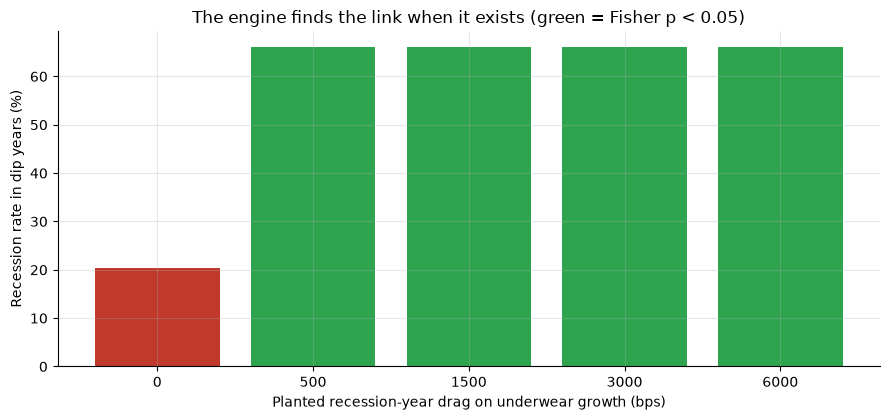

 bps  rec|dip%  rec|nodip%  fisher_p
   0     20.45       16.57    0.3216
 500     66.02        0.00    0.0000
1500     66.02        0.00    0.0000
3000     66.02        0.00    0.0000
6000     66.02        0.00    0.0000


In [8]:
planted = [0, 500, 1500, 3000, 6000]
rows = []
for bps in planted:
    df_s, _ = data.synthetic_annual(n_years=400, signal_bps=float(bps), seed=270)
    # build the next-year flags the same way fetch does
    df_s = df_s.sort_values('year').reset_index(drop=True)
    df_s['next_recession'] = df_s['recession'].shift(-1).fillna(False).astype(bool)
    r = st.recession_stats(df_s, horizon='same', n_permutations=400, seed=99)
    rows.append({'bps': bps, 'rec|dip%': r['rec_rate_dip']*100,
                 'rec|nodip%': r['rec_rate_nodip']*100, 'fisher_p': r['fisher_p']})
res = pd.DataFrame(rows)
colors = [GREEN if rr['fisher_p'] < 0.05 else RED for rr in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(rr['bps']) for rr in rows], [rr['rec|dip%'] for rr in rows], color=colors)
ax.set_xlabel('Planted recession-year drag on underwear growth (bps)')
ax.set_ylabel('Recession rate in dip years (%)')
ax.set_title('The engine finds the link when it exists (green = Fisher p < 0.05)')
plt.tight_layout(); plt.show()
print(res.to_string(index=False))

With a large planted drag and n=400 the engine cleanly detects the dip->recession link. The real tape -- n=33, 4 dips, no forward signal -- is nowhere near. The verdict is a statement about **the indicator and the sample**, not the method.